# House Price Prediction

## Oasis Infobyte Data Analytics Internship

### Predicting House Prices with Linear Regression

## import libraries

In [42]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

## load dataset

In [46]:
# Load dataset

df = pd.read_csv("../data/Housing.csv")

# Display first five rows

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### dataset shape

In [48]:
# Check number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


### dataset information

In [50]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### column names

In [52]:
# Display column names

df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

### missing values

In [54]:
# Check missing values

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### duplicate records

In [56]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## exploratory data analysis

### descriptive statistics

In [58]:
# Display descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


### price distribution

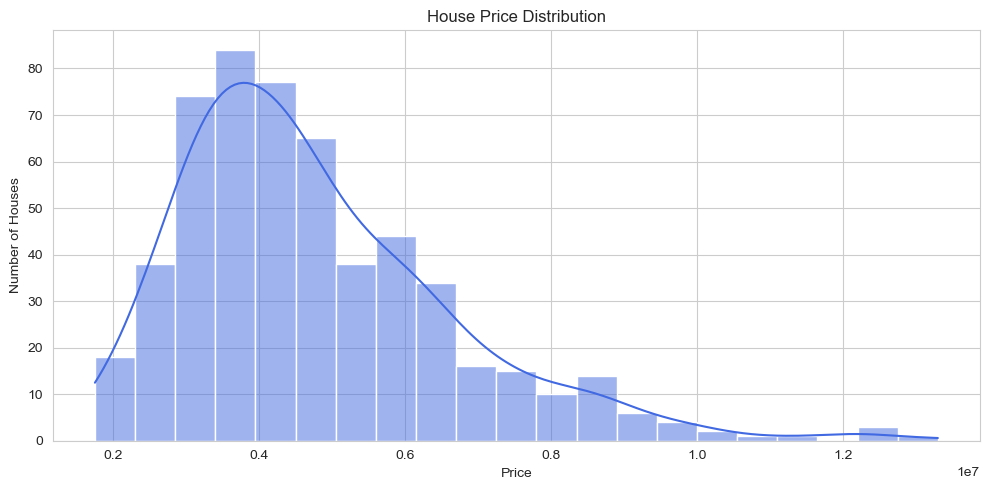

In [64]:
# Plot house price distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df["price"],
    kde=True,
    color="royalblue"
)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.tight_layout()

plt.savefig(
    "../results/plots/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### area distribution

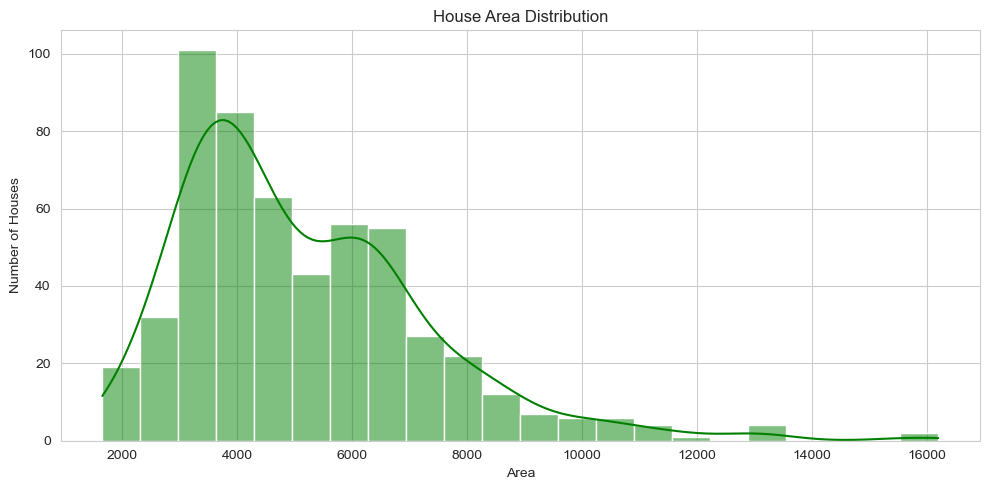

In [66]:
# Plot area distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    df["area"],
    kde=True,
    color="green"
)

plt.title("House Area Distribution")
plt.xlabel("Area")
plt.ylabel("Number of Houses")

plt.tight_layout()

plt.savefig(
    "../results/plots/area_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## feature selection

### selected features

The main features selected for house price prediction are area, bedrooms, bathrooms, stories, parking, mainroad, guestroom, basement, airconditioning, prefarea, and furnishing status.

These features describe the size, facilities, location preference, and furnishing condition of a house and may influence its price.

The target variable is price.

### identify feature types

In [68]:
# Separate target and features

X = df.drop("price", axis=1)
y = df["price"]

# Identify numerical and categorical columns

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


## correlation analysis

### correlation heatmap

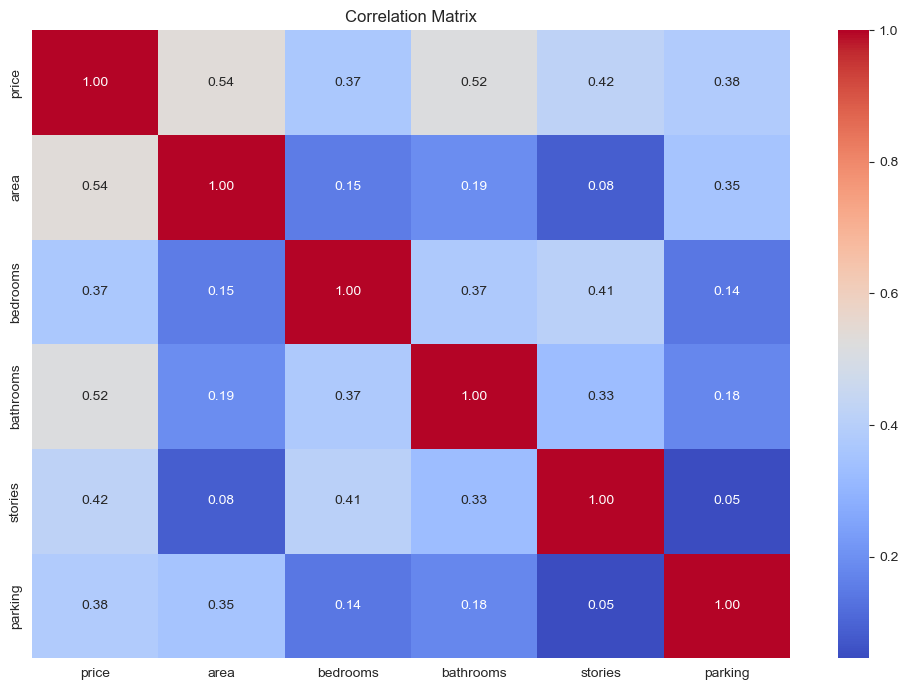

In [70]:
# Calculate correlation matrix

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

# Plot correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../results/plots/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### area vs price

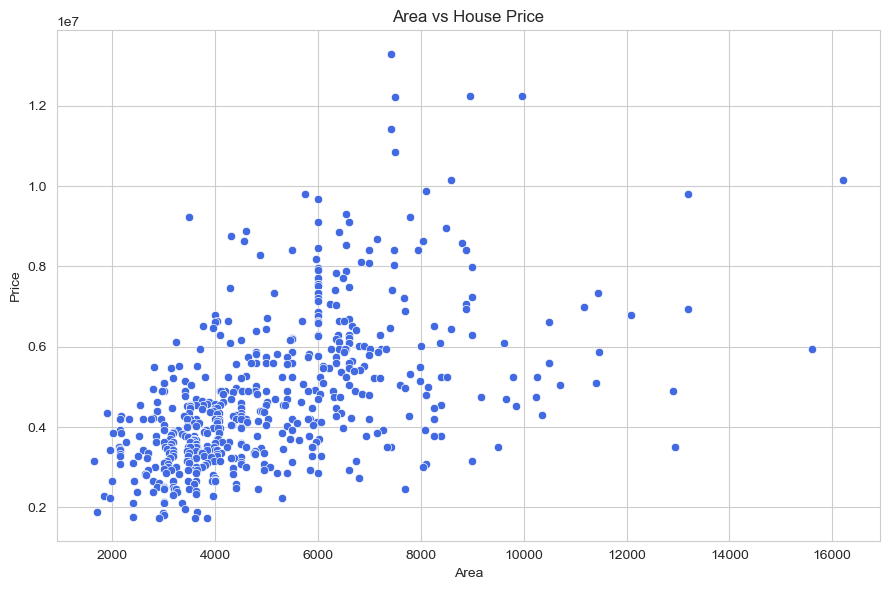

In [72]:
# Plot area against price

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="area",
    y="price",
    color="royalblue"
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.tight_layout()

plt.savefig(
    "../results/plots/area_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## data preprocessing

### handle missing values and encode categorical features

In [74]:
# Numerical preprocessing

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing steps

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## train test split

In [76]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 436
Testing rows: 109


## linear regression model

In [78]:
# Create Linear Regression pipeline

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### generate predictions

In [80]:
# Predict house prices

y_pred = linear_model.predict(X_test)

# Display first predictions

predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

predictions.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


## model evaluation

In [82]:
# Calculate evaluation metrics

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 1754318687330.6616
Root Mean Squared Error (RMSE): 1324506.960091438
R² Score: 0.6529242642153188


### model performance

In [91]:
# Create model performance table

model_performance = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MSE": [mse],
    "RMSE": [rmse],
    "R2 Score": [r2]
})

model_performance

,Model,MSE,RMSE,R2 Score
0,Linear Regression,1.754319e+12,1.324507e+06,0.652924


In [93]:
# Save model performance

model_performance.to_csv(
    "../results/metrics/model_performance.csv",
    index=False
)

print("Model performance saved successfully.")

Model performance saved successfully.


## actual vs predicted prices

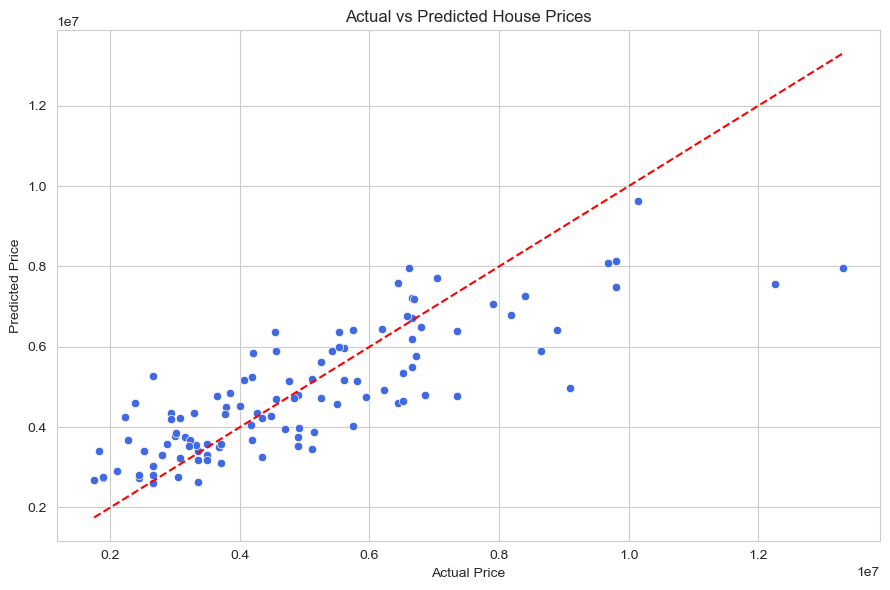

In [95]:
# Plot actual vs predicted prices

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color="royalblue"
)

# Diagonal reference line

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()

plt.savefig(
    "../results/plots/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## residual analysis

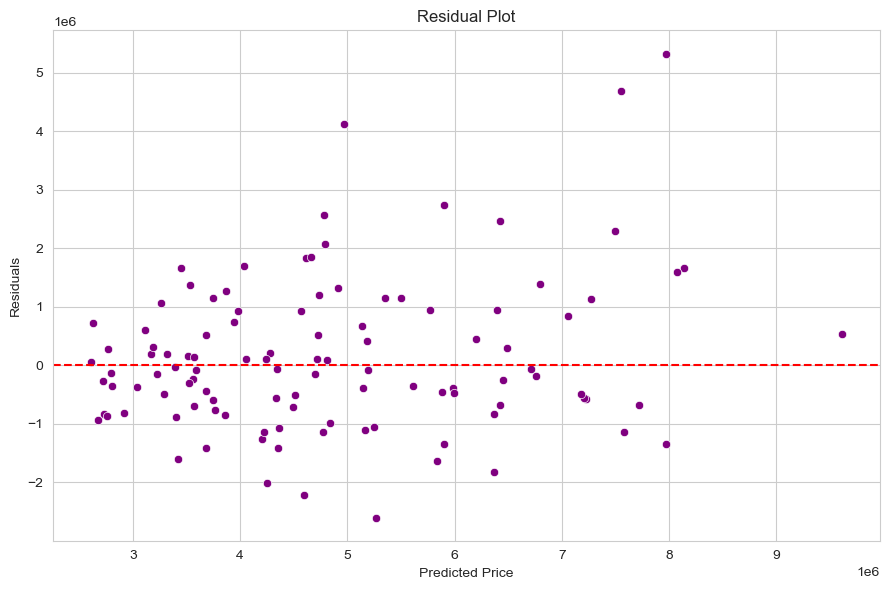

In [97]:
# Calculate residuals

residuals = y_test - y_pred

# Plot residuals

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    color="purple"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.tight_layout()

plt.savefig(
    "../results/plots/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## coefficient analysis

In [110]:
# Get transformed feature names

feature_names = linear_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get model coefficients

coefficients = linear_model.named_steps[
    "model"
].coef_

# Create coefficient dataframe

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort coefficients

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df.head(10)

,Feature,Coefficient
2,num__bathrooms,1.094445e+06
3,num__stories,4.074766e+05
14,cat__airconditioning_yes,3.957134e+05
12,cat__hotwaterheating_yes,3.423249e+05
16,cat__prefarea_yes,3.149453e+05
4,num__parking,2.248419e+05
10,cat__basement_yes,1.951256e+05
6,cat__mainroad_yes,1.839600e+05
17,cat__furnishingstatus_furnished,1.801756e+05
8,cat__guestroom_yes,1.158050e+05


### highest positive and negative coefficients

In [112]:
# Select strongest positive and negative coefficients

top_positive = coefficient_df.head(5)

top_negative = coefficient_df.tail(5)

print("Highest Positive Coefficients:")
display(top_positive)

print("\nHighest Negative Coefficients:")
display(top_negative)

Highest Positive Coefficients:


,Feature,Coefficient
2,num__bathrooms,1.094445e+06
3,num__stories,4.074766e+05
14,cat__airconditioning_yes,3.957134e+05
12,cat__hotwaterheating_yes,3.423249e+05
16,cat__prefarea_yes,3.149453e+05



Highest Negative Coefficients:


,Feature,Coefficient
9,cat__basement_no,-195125.588091
19,cat__furnishingstatus_unfurnished,-233469.435624
15,cat__prefarea_no,-314945.282657
11,cat__hotwaterheating_no,-342324.942669
13,cat__airconditioning_no,-395713.367922


### coefficient impact

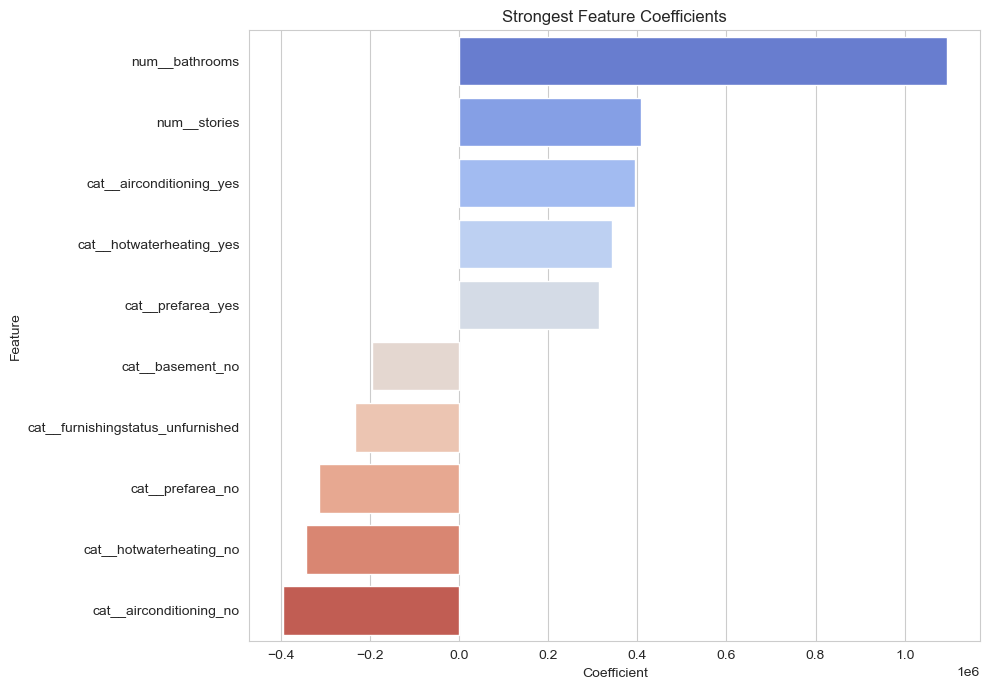

In [114]:
# Select strongest coefficients

top_coefficients = pd.concat([
    coefficient_df.head(5),
    coefficient_df.tail(5)
])

# Plot coefficients

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    palette="coolwarm",
    legend=False
)

plt.title("Strongest Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../results/plots/coefficient_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## save predictions

In [116]:
# Save actual and predicted prices

predictions.to_csv(
    "../results/predictions/house_price_predictions.csv",
    index=False
)

print("Predictions saved successfully.")

Predictions saved successfully.


## conclusion
The Linear Regression model successfully predicted house prices using property features.

The model was evaluated using MSE, RMSE, and R² score.

The analysis also identified important features affecting house prices and compared actual prices with predicted prices.regularised model.